In [1]:
%pip install pandas
%pip install yfinance
%pip install matplotlib
%pip install scipy
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 17.2 MB/s  0:00:00 eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] 1/2 [statsmodels]
Note: you may need to restart the kernel to use updated packages.


# Fama-French dataset

It's worth noting that 1.00 in this dataset means 1%, not 100%

[[1]](https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html) Dartmouth College, French, K.R (2025) *Current Research Returns* Available at: https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html (Accessed: 17 December 2025)

In [2]:
from pandas import DataFrame, read_csv

path: str = "data/F-F_Research_Data_5_Factors_2x3_daily.csv"
fama_french: DataFrame = read_csv(path)

In [3]:
fama_french.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15690 entries, 19630701 to 20251031
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Mkt-RF  15690 non-null  float64
 1   SMB     15690 non-null  float64
 2   HML     15690 non-null  float64
 3   RMW     15690 non-null  float64
 4   CMA     15690 non-null  float64
 5   RF      15690 non-null  float64
dtypes: float64(6)
memory usage: 858.0 KB


In [4]:
fama_french.index.dtype

dtype('int64')

In [5]:
fama_french.head()

,Mkt-RF,SMB,HML,RMW,CMA,RF
19630701,-0.67,0.00,-0.34,-0.01,0.16,0.01
19630702,0.79,-0.26,0.26,-0.07,-0.20,0.01
19630703,0.63,-0.17,-0.09,0.18,-0.34,0.01
19630705,0.40,0.08,-0.27,0.09,-0.34,0.01
19630708,-0.63,0.04,-0.18,-0.29,0.14,0.01


In [6]:
fama_french.tail()

,Mkt-RF,SMB,HML,RMW,CMA,RF
20251027,1.17,-0.81,-1.21,-0.23,-1.19,0.02
20251028,0.18,-0.34,-0.61,0.63,-1.01,0.02
20251029,-0.09,-0.98,-0.81,0.30,-1.37,0.02
20251030,-1.10,0.00,0.67,-0.27,0.42,0.02
20251031,0.40,-0.07,-0.24,-1.31,0.18,0.02


In [7]:
fama_french.isna().sum()

Mkt-RF    0
SMB       0
HML       0
RMW       0
CMA       0
RF        0
dtype: int64

In [8]:
from pandas import to_datetime
fama_french.index = to_datetime(fama_french.index, format = "%Y%m%d").strftime("%Y-%m-%d")
fama_french.index = fama_french.index.astype("datetime64[ns]")

In [9]:
fama_french.index.dtype

dtype('<M8[ns]')

<Axes: title={'center': 'Fama-French Cumulative'}, xlabel='Date', ylabel='%'>

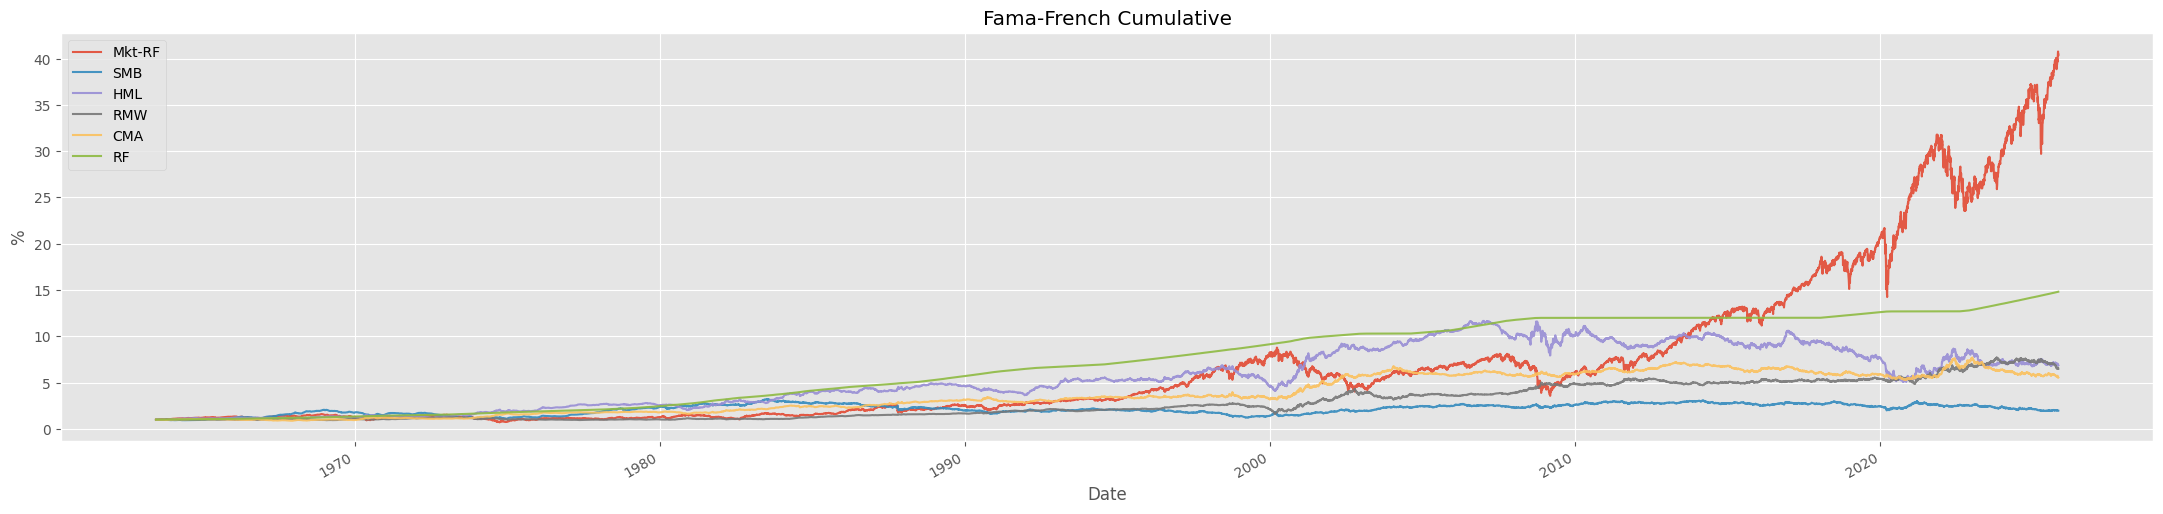

In [10]:
import matplotlib.pyplot as plt
from pandas import DataFrame

plt.style.use("ggplot")

fama_french_percentage: DataFrame = (1 + fama_french / 100) # converts ie. 1.00 = 1% -> 0.01 = 1%
fama_french_percentage_cumprod: DataFrame = fama_french_percentage.cumprod()
fama_french_percentage_cumprod.plot(grid = True, figsize = (27, 6), alpha = 0.9, title = "Fama-French Cumulative", xlabel = "Date", ylabel = "%")

# Ticker market dataset

Collection of some arbitrary markets that may be interesting to plot and train with; leaning towards Apple, AAPL, just because, but really valid ticker is possible

In [11]:
from yfinance import download
from pandas import DataFrame
market: dict = {
  "LLOY.L": "Lloyds Banking Group plc", 
  "HSBC": "HSBC Holdings plc",
  "AAPL": "Apple Inc",
  "NVDA": "NVIDIA Corporation",
  "TSCO.L": "Tesco PLC"
}
if (fetched_tickers := download(list(market.keys()), start = "2000-01-01")) is None: 
  raise ValueError("Error with the market ticker keys, check again against Yahoo Finance for the correct details") 

tickers: DataFrame = fetched_tickers

/tmp/ipykernel_35927/2223486807.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  if (fetched_tickers := download(list(market.keys()), start = "2000-01-01")) is None:
[*********************100%***********************]  5 of 5 completed


In [12]:
tickers.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6709 entries, 2000-01-03 to 2026-01-02
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   (Close, AAPL)     6540 non-null   float64
 1   (Close, HSBC)     6540 non-null   float64
 2   (Close, LLOY.L)   6619 non-null   float64
 3   (Close, NVDA)     6540 non-null   float64
 4   (Close, TSCO.L)   6619 non-null   float64
 5   (High, AAPL)      6540 non-null   float64
 6   (High, HSBC)      6540 non-null   float64
 7   (High, LLOY.L)    6619 non-null   float64
 8   (High, NVDA)      6540 non-null   float64
 9   (High, TSCO.L)    6619 non-null   float64
 10  (Low, AAPL)       6540 non-null   float64
 11  (Low, HSBC)       6540 non-null   float64
 12  (Low, LLOY.L)     6619 non-null   float64
 13  (Low, NVDA)       6540 non-null   float64
 14  (Low, TSCO.L)     6619 non-null   float64
 15  (Open, AAPL)      6540 non-null   float64
 16  (Open, HSBC)      6540 n

In [13]:
tickers.index.dtype

dtype('<M8[ns]')

In [14]:
tickers.head()

Price          Close                                                   High  \
Ticker          AAPL       HSBC      LLOY.L      NVDA      TSCO.L      AAPL   
Date                                                                          
2000-01-03  0.839281  19.393667  497.945465  0.089415  236.190353  0.843498   
2000-01-04  0.768521  18.210501  466.763611  0.087028  228.034943  0.829440   
2000-01-05  0.779767  18.107615  466.120605  0.084163  231.798965  0.828971   
2000-01-06  0.712287  17.593193  450.690491  0.078671  231.798965  0.802260   
2000-01-07  0.746027  18.090469  434.938782  0.079985  228.662415  0.757274   

Price                                                    ...      Open  \
Ticker           HSBC      LLOY.L      NVDA      TSCO.L  ...      AAPL   
Date                                                     ...             
2000-01-03  19.616583  497.945465  0.090967  236.190353  ...  0.786328   
2000-01-04  18.656332  466.763611  0.088102  237.131315  ...  0.811633   
2000-01-05  18.193351  466.120605  0.085953  233.994665  ...  0.777892   
2000-01-06  17.661783  450.690491  0.084163  234.621965  ...  0.795700   
2000-01-07  18.090469  434.938782  0.080820  237.131400  ...  0.723534   

Price                                                         Volume  \
Ticker           HSBC      LLOY.L      NVDA      TSCO.L         AAPL   
Date                                                                   
2000-01-03  19.599436  497.945465  0.090251  236.190353  535796800.0   
2000-01-04  18.399122  466.763611  0.087863  237.131315  512377600.0   
2000-01-05  17.764667  466.120605  0.084521  220.820693  778321600.0   
2000-01-06  17.558898  450.690491  0.084163  231.798965  767972800.0   
2000-01-07  17.490312  434.938782  0.078313  234.622004  460734400.0   

Price                                                      
Ticker          HSBC      LLOY.L         NVDA      TSCO.L  
Date                                                       
2000-01-03   59500.0         0.0  300912000.0         0.0  
2000-01-04   84500.0  21285517.0  300480000.0  11214410.0  
2000-01-05  118200.0  26030803.0  188352000.0   9228302.0  
2000-01-06  105400.0  43870695.0  120480000.0  11398336.0  
2000-01-07  117700.0  38938371.0   71184000.0  13505834.0  

[5 rows x 25 columns]

In [15]:
tickers.tail()

Price            Close                                                \
Ticker            AAPL       HSBC     LLOY.L        NVDA      TSCO.L   
Date                                                                   
2025-12-26  273.399994  79.970001        NaN  190.529999         NaN   
2025-12-29  273.760010  78.849998  97.260002  188.220001  440.299988   
2025-12-30  273.079987  79.279999  98.339996  187.539993  443.600006   
2025-12-31  271.859985  78.669998  98.239998  186.500000  441.799988   
2026-01-02  271.010010  80.449997  99.239998  188.850006  442.200012   

Price             High                                                 ...  \
Ticker            AAPL       HSBC      LLOY.L        NVDA      TSCO.L  ...   
Date                                                                   ...   
2025-12-26  275.369995  79.970001         NaN  192.690002         NaN  ...   
2025-12-29  274.359985  79.260002   97.879997  188.759995  440.799988  ...   
2025-12-30  274.079987  79.680000   98.620003  188.990005  443.600006  ...   
2025-12-31  273.679993  79.260002   98.720001  190.559998  446.200012  ...   
2026-01-02  277.839996  80.820000  100.224998  192.929993  445.299988  ...   

Price             Open                                                \
Ticker            AAPL       HSBC     LLOY.L        NVDA      TSCO.L   
Date                                                                   
2025-12-26  274.160004  79.599998        NaN  189.919998         NaN   
2025-12-29  272.690002  79.120003  97.000000  187.710007  437.799988   
2025-12-30  272.809998  79.650002  97.199997  188.240005  440.500000   
2025-12-31  273.059998  79.239998  98.540001  189.570007  446.100006   
2026-01-02  272.260010  80.800003  98.239998  189.839996  442.899994   

Price           Volume                                                   
Ticker            AAPL       HSBC       LLOY.L         NVDA      TSCO.L  
Date                                                                     
2025-12-26  21521800.0   669000.0          NaN  139740300.0         NaN  
2025-12-29  23715200.0   996500.0   47048532.0  120006100.0   5470561.0  
2025-12-30  22139600.0  1415900.0   38062581.0   97687300.0  11248755.0  
2025-12-31  27293600.0   822400.0   27897581.0  120100500.0   2800926.0  
2026-01-02  37822400.0  2228600.0  132175167.0  147941400.0   7804845.0  

[5 rows x 25 columns]

In [16]:
tickers.isna().sum()

Price   Ticker
Close   AAPL      169
        HSBC      169
        LLOY.L     90
        NVDA      169
        TSCO.L     90
High    AAPL      169
        HSBC      169
        LLOY.L     90
        NVDA      169
        TSCO.L     90
Low     AAPL      169
        HSBC      169
        LLOY.L     90
        NVDA      169
        TSCO.L     90
Open    AAPL      169
        HSBC      169
        LLOY.L     90
        NVDA      169
        TSCO.L     90
Volume  AAPL      169
        HSBC      169
        LLOY.L     90
        NVDA      169
        TSCO.L     90
dtype: int64

In [17]:
import matplotlib.pyplot as plt
import matplotlib.axes as ax
#TODO- live hover it needed to make sure lines more visable

plt.style.use("ggplot")

def plot_ticker(ticker: str):
  """ General plot for ticker information
  """
  figure, axes = plt.subplots(1, 1)
  figure.set_figwidth(27)
  figure.set_figheight(6)
  figure.suptitle(ticker)

  axes.plot(tickers["Open"][ticker], alpha = 0.2, color = "yellow")
  axes.plot(tickers["Close"][ticker], color = "purple")
  axes.plot(tickers["High"][ticker], alpha = 0.5, color = "green")
  axes.plot(tickers["Low"][ticker], alpha = 0.5, color = "red")
  axes.set_ylabel("$")
  axes.set_xlabel("Date")
  axes_ext: ax.Axes = axes.twinx()

  axes_ext.bar(tickers.index, tickers["Volume"][ticker], color = "grey", alpha = 0.5)
  axes_ext.set_ylabel("Volumes")
  axes_ext.set_xlabel("Date")

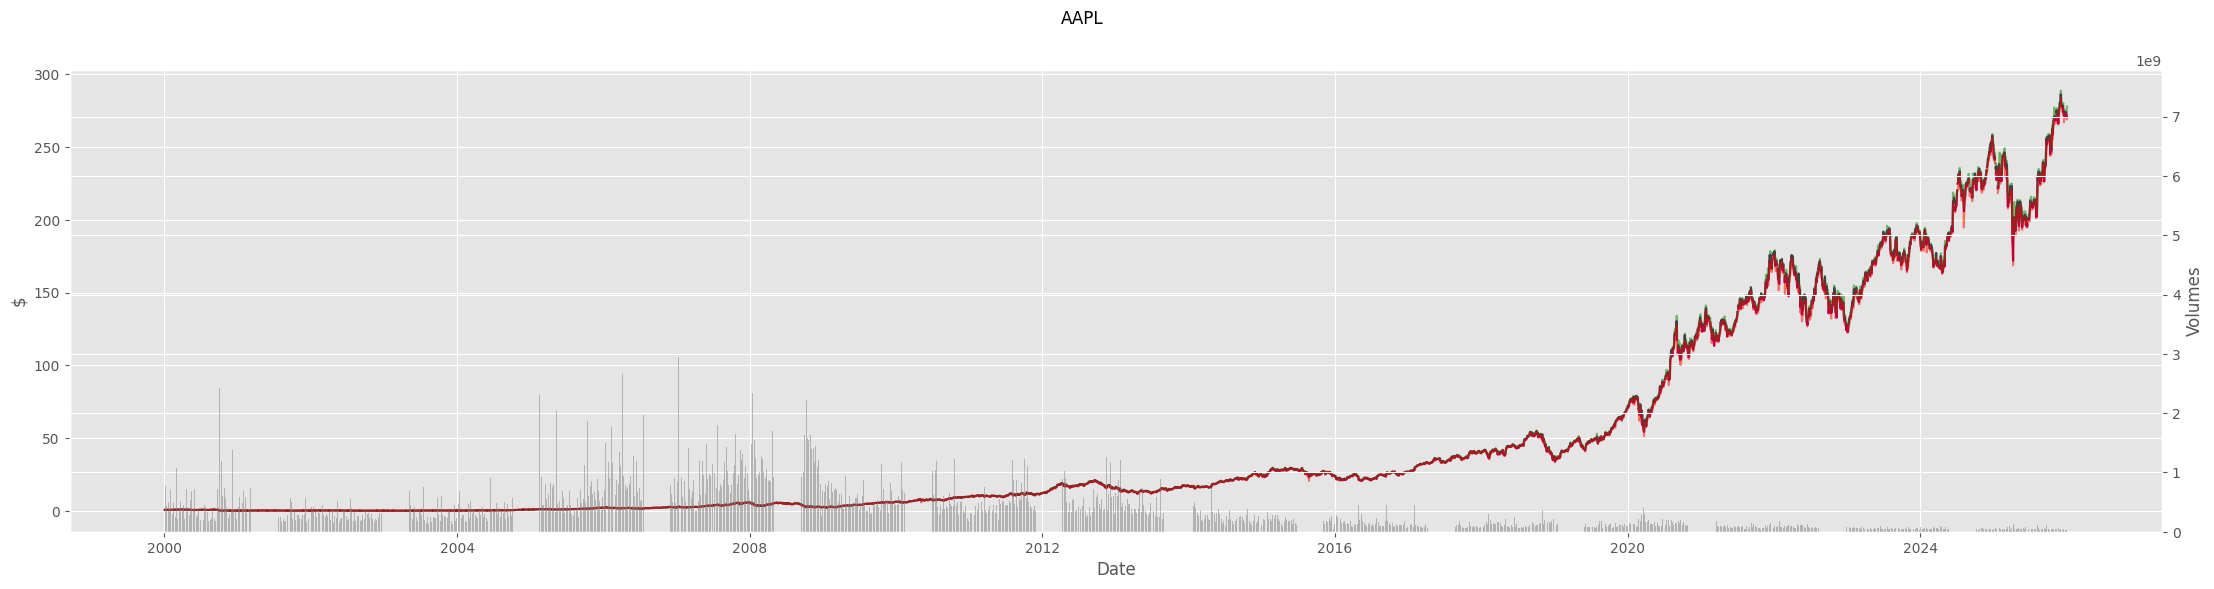

In [18]:
plot_ticker("AAPL")

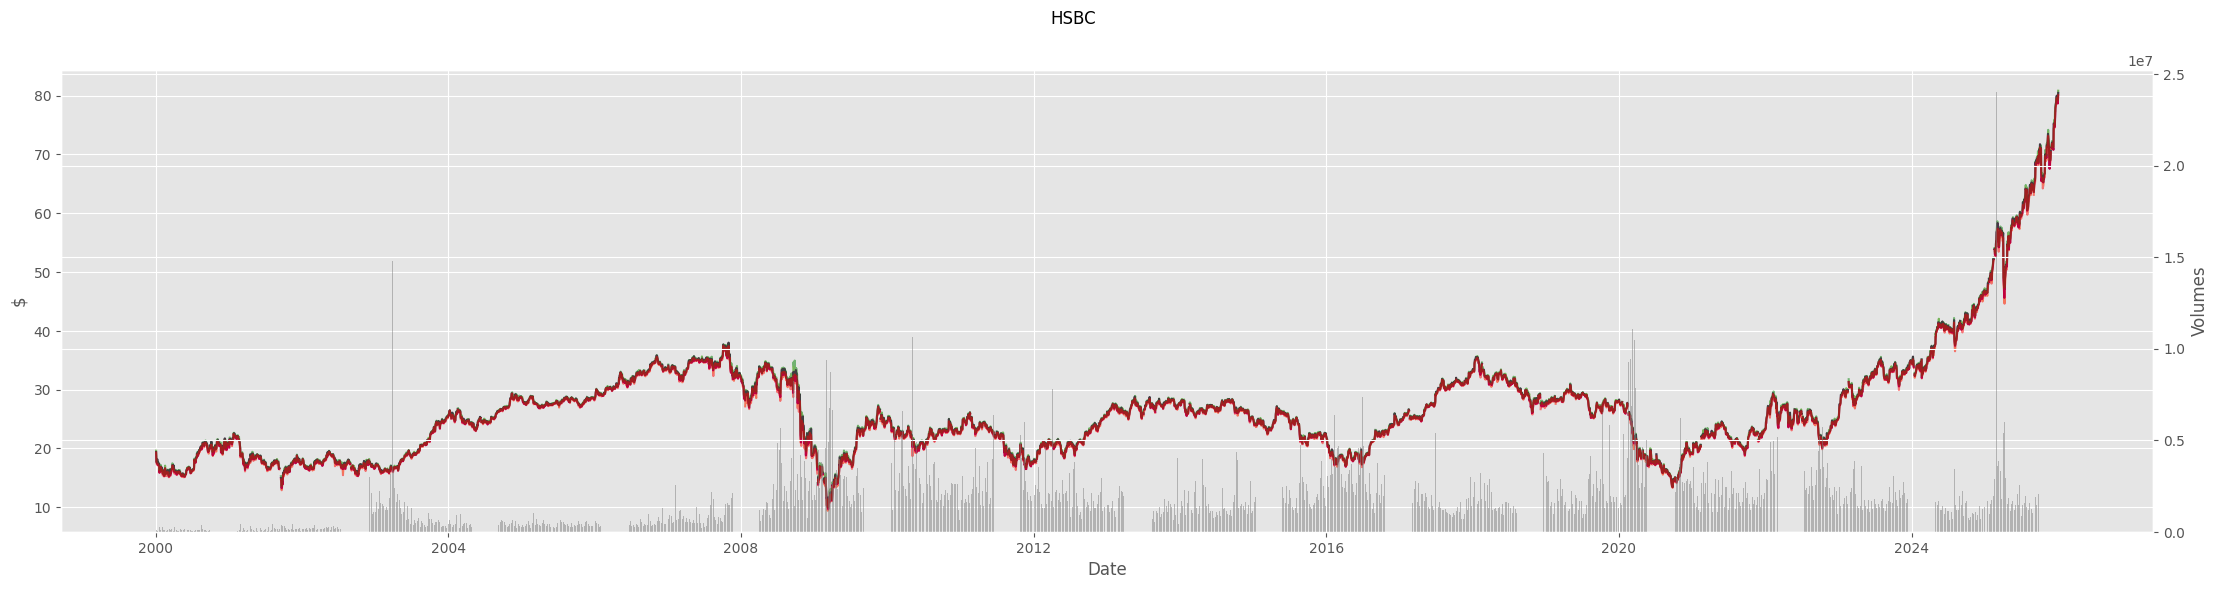

In [19]:
plot_ticker("HSBC")

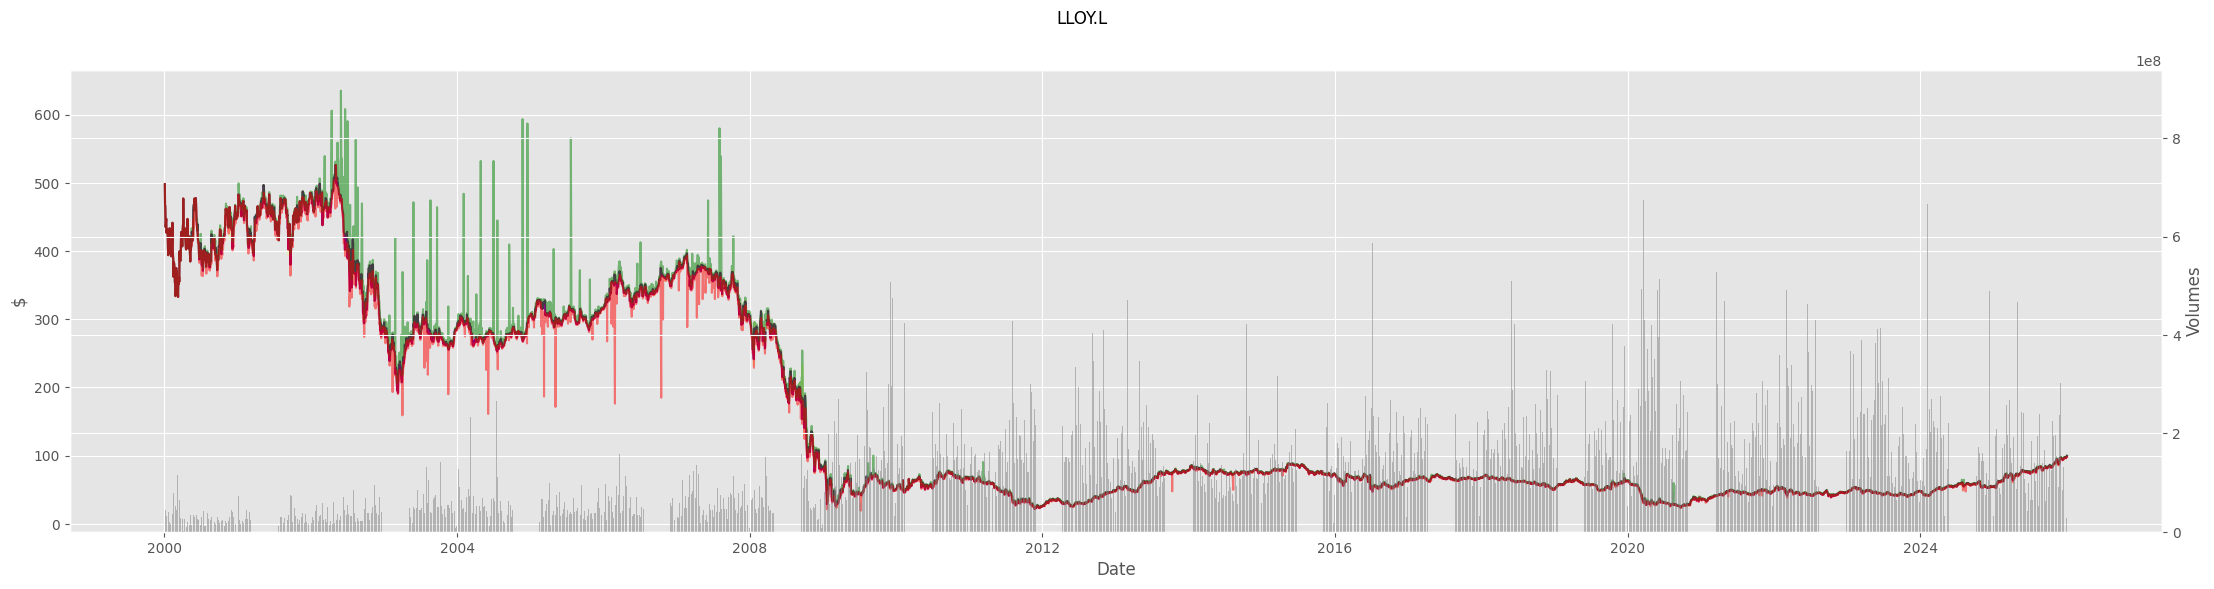

In [20]:
plot_ticker("LLOY.L")

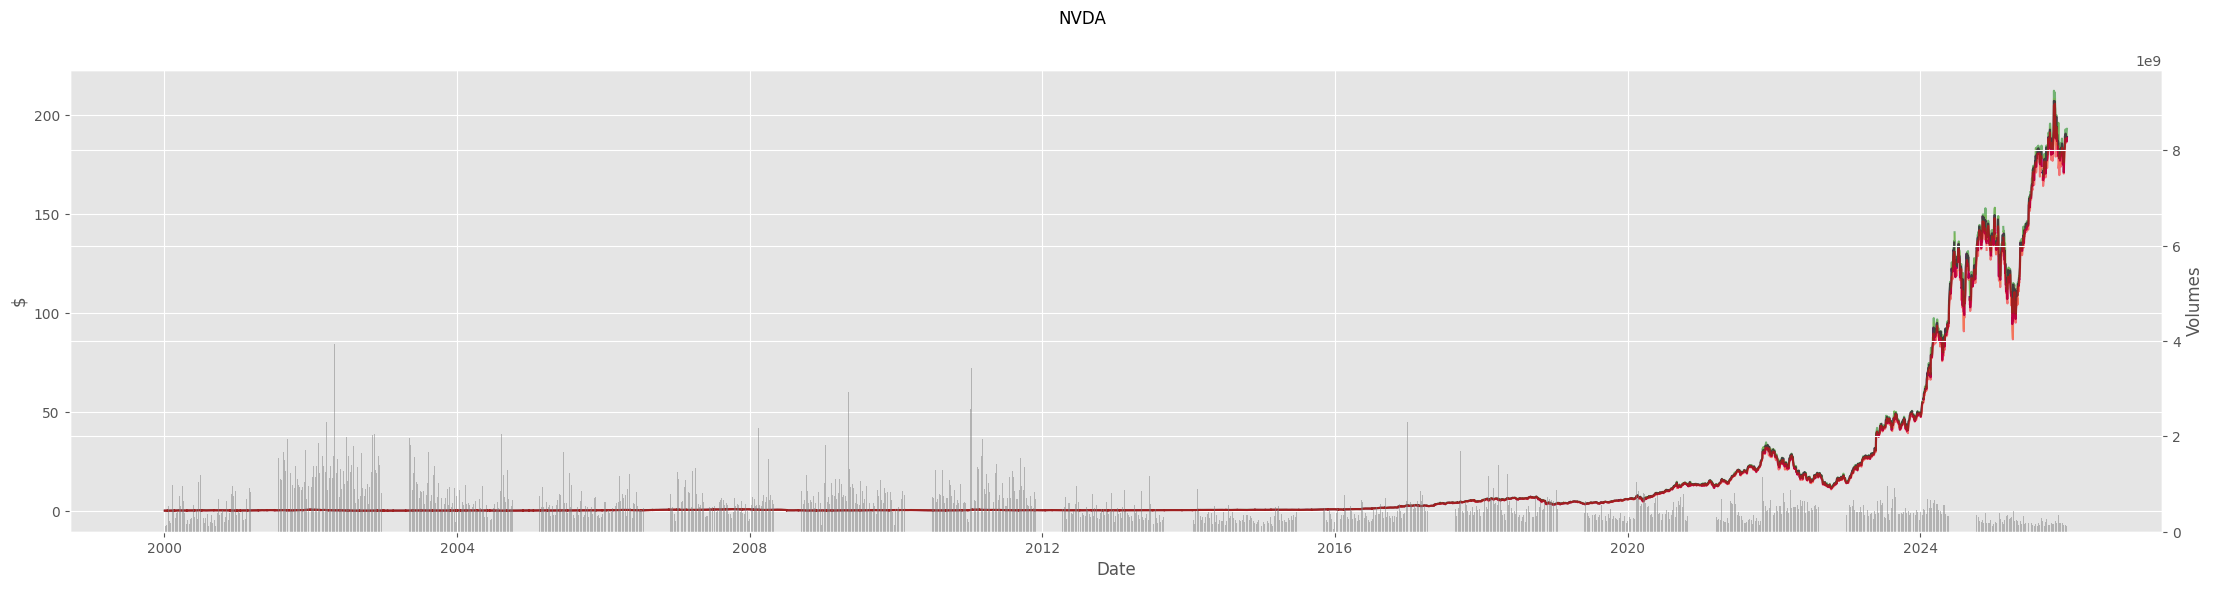

In [21]:
plot_ticker("NVDA")

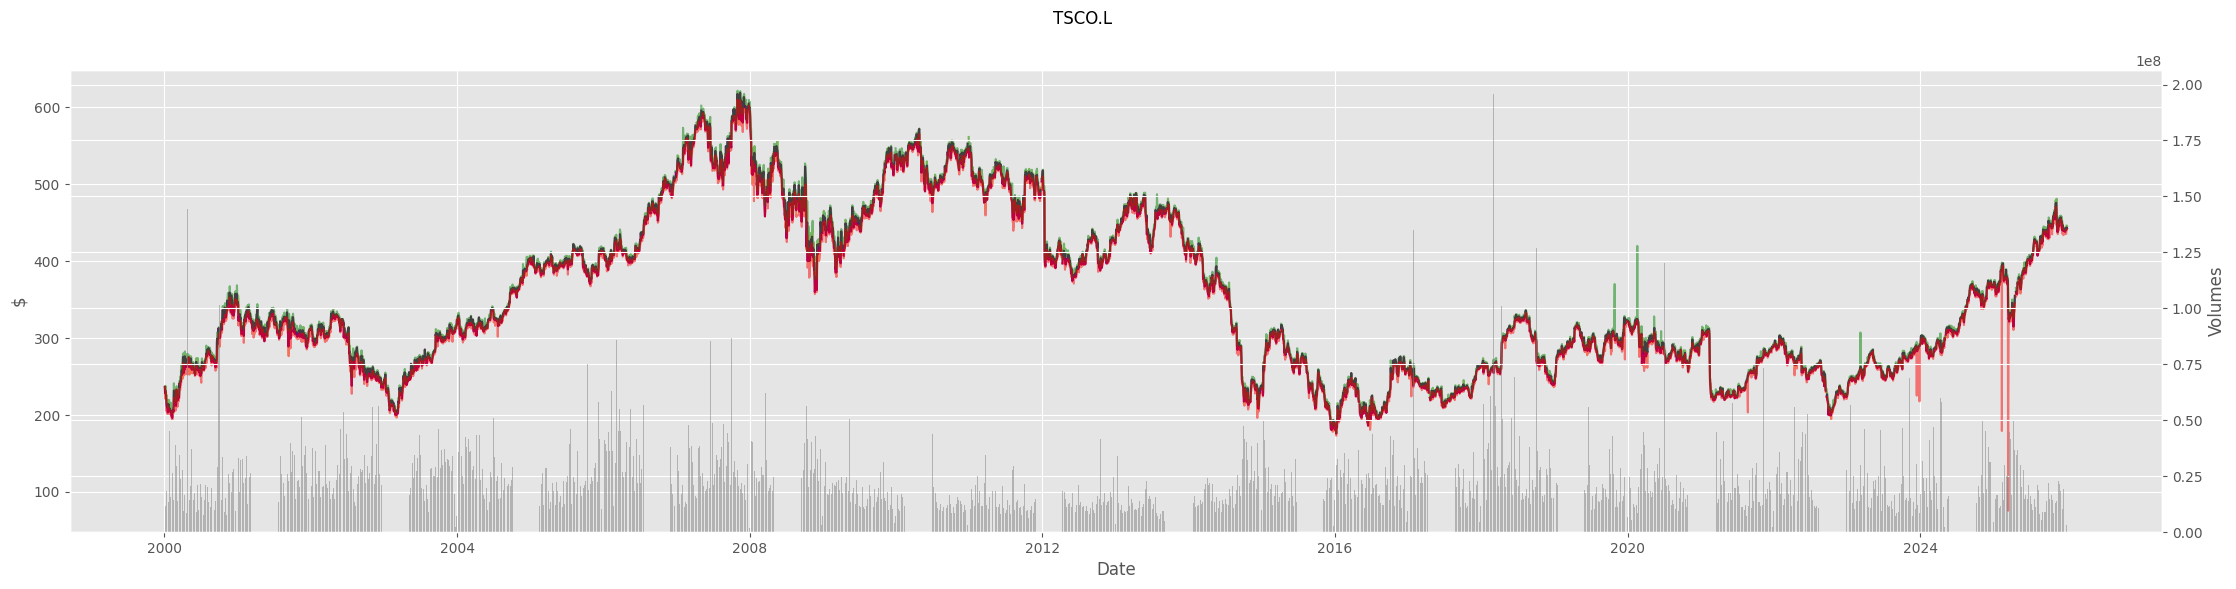

In [22]:
plot_ticker("TSCO.L")

In [23]:
from pandas import DataFrame

small_imputation_tickers: DataFrame = tickers.copy()

limit: int = 2

small_imputation_tickers["Close"] = small_imputation_tickers["Close"].ffill(limit = limit)
small_imputation_tickers["Open"] = small_imputation_tickers["Open"].ffill(limit = limit)
small_imputation_tickers["Low"] = small_imputation_tickers["Low"].ffill(limit = limit)
small_imputation_tickers["High"] = small_imputation_tickers["High"].ffill(limit = limit)
small_imputation_tickers["Volume"] = small_imputation_tickers["Volume"].ffill(limit = limit)

In [24]:
small_imputation_tickers.isna().sum()

Price   Ticker
Close   AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
High    AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Low     AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Open    AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Volume  AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
dtype: int64

In [25]:
small_imputation_tickers[small_imputation_tickers.isna().any(axis = 1)]

Price      Close                                   High                        \
Ticker      AAPL HSBC      LLOY.L NVDA      TSCO.L AAPL HSBC      LLOY.L NVDA   
Date                                                                            
2001-09-13   NaN  NaN  437.597260  NaN  315.028412  NaN  NaN  437.597260  NaN   
2001-09-14   NaN  NaN  419.578552  NaN  322.872589  NaN  NaN  438.884362  NaN   

Price                   ... Open                                   Volume  \
Ticker          TSCO.L  ... AAPL HSBC      LLOY.L NVDA      TSCO.L   AAPL   
Date                    ...                                                 
2001-09-13  315.028412  ...  NaN  NaN  437.597260  NaN  311.539192    NaN   
2001-09-14  331.344488  ...  NaN  NaN  419.578552  NaN  315.028325    NaN   

Price                                         
Ticker     HSBC      LLOY.L NVDA      TSCO.L  
Date                                          
2001-09-13  NaN  26036252.0  NaN  22200826.0  
2001-09-14  NaN  26752117.0  NaN  24419843.0  

[2 rows x 25 columns]

In [26]:
small_imputation_tickers.dropna(inplace = False)

Price            Close                                                 \
Ticker            AAPL       HSBC      LLOY.L        NVDA      TSCO.L   
Date                                                                    
2000-01-03    0.839281  19.393667  497.945465    0.089415  236.190353   
2000-01-04    0.768521  18.210501  466.763611    0.087028  228.034943   
2000-01-05    0.779767  18.107615  466.120605    0.084163  231.798965   
2000-01-06    0.712287  17.593193  450.690491    0.078671  231.798965   
2000-01-07    0.746027  18.090469  434.938782    0.079985  228.662415   
...                ...        ...         ...         ...         ...   
2025-12-26  273.399994  79.970001   97.000000  190.529999  438.000000   
2025-12-29  273.760010  78.849998   97.260002  188.220001  440.299988   
2025-12-30  273.079987  79.279999   98.339996  187.539993  443.600006   
2025-12-31  271.859985  78.669998   98.239998  186.500000  441.799988   
2026-01-02  271.010010  80.449997   99.239998  188.850006  442.200012   

Price             High                                                 ...  \
Ticker            AAPL       HSBC      LLOY.L        NVDA      TSCO.L  ...   
Date                                                                   ...   
2000-01-03    0.843498  19.616583  497.945465    0.090967  236.190353  ...   
2000-01-04    0.829440  18.656332  466.763611    0.088102  237.131315  ...   
2000-01-05    0.828971  18.193351  466.120605    0.085953  233.994665  ...   
2000-01-06    0.802260  17.661783  450.690491    0.084163  234.621965  ...   
2000-01-07    0.757274  18.090469  434.938782    0.080820  237.131400  ...   
...                ...        ...         ...         ...         ...  ...   
2025-12-26  275.369995  79.970001   98.029999  192.690002  441.399994  ...   
2025-12-29  274.359985  79.260002   97.879997  188.759995  440.799988  ...   
2025-12-30  274.079987  79.680000   98.620003  188.990005  443.600006  ...   
2025-12-31  273.679993  79.260002   98.720001  190.559998  446.200012  ...   
2026-01-02  277.839996  80.820000  100.224998  192.929993  445.299988  ...   

Price             Open                                                 \
Ticker            AAPL       HSBC      LLOY.L        NVDA      TSCO.L   
Date                                                                    
2000-01-03    0.786328  19.599436  497.945465    0.090251  236.190353   
2000-01-04    0.811633  18.399122  466.763611    0.087863  237.131315   
2000-01-05    0.777892  17.764667  466.120605    0.084521  220.820693   
2000-01-06    0.795700  17.558898  450.690491    0.084163  231.798965   
2000-01-07    0.723534  17.490312  434.938782    0.078313  234.622004   
...                ...        ...         ...         ...         ...   
2025-12-26  274.160004  79.599998   97.580002  189.919998  439.299988   
2025-12-29  272.690002  79.120003   97.000000  187.710007  437.799988   
2025-12-30  272.809998  79.650002   97.199997  188.240005  440.500000   
2025-12-31  273.059998  79.239998   98.540001  189.570007  446.100006   
2026-01-02  272.260010  80.800003   98.239998  189.839996  442.899994   

Price            Volume                                                   
Ticker             AAPL       HSBC       LLOY.L         NVDA      TSCO.L  
Date                                                                      
2000-01-03  535796800.0    59500.0          0.0  300912000.0         0.0  
2000-01-04  512377600.0    84500.0   21285517.0  300480000.0  11214410.0  
2000-01-05  778321600.0   118200.0   26030803.0  188352000.0   9228302.0  
2000-01-06  767972800.0   105400.0   43870695.0  120480000.0  11398336.0  
2000-01-07  460734400.0   117700.0   38938371.0   71184000.0  13505834.0  
...                 ...        ...          ...          ...         ...  
2025-12-26   21521800.0   669000.0   24322694.0  139740300.0   2284579.0  
2025-12-29   23715200.0   996500.0   47048532.0  120006100.0   5470561.0  
2025-12-30   22139600.0  1415900.0  

In [27]:
small_imputation_tickers.isna().sum()

Price   Ticker
Close   AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
High    AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Low     AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Open    AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
Volume  AAPL      2
        HSBC      2
        LLOY.L    0
        NVDA      2
        TSCO.L    0
dtype: int64

# Preparing the dependant variable y, excess returns 

We'll select Apple, AAPL as the target ticker arbitrarily, however, realistically it could have been valid ticker

In [28]:
from pandas import Series

# pct_change() returns in format 0.01 = 1% thus we must change the format to match FF 0.01 = 1% -> 1.00 = 1%
# dropna() for the first sample given pct_change() cannot calculate the change from one value
total_returns: Series = (small_imputation_tickers["Close"].pct_change()) * 100
total_returns.dropna(inplace = True)

/tmp/ipykernel_35927/1977192223.py:5: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  total_returns: Series = (small_imputation_tickers["Close"].pct_change()) * 100


In [29]:
total_returns.head()

Ticker,AAPL,HSBC,LLOY.L,NVDA,TSCO.L
Date,,,,,
2000-01-04,-8.430996,-6.100788,-6.262102,-2.670071,-3.452897
2000-01-05,1.463318,-0.564983,-0.137758,-3.292192,1.650634
2000-01-06,-8.653827,-2.840912,-3.310327,-6.525233,0.000000
2000-01-07,4.736893,2.826527,-3.495017,1.670013,-1.353134
2000-01-10,-1.758824,0.094775,2.808581,3.282900,-3.155071


In [30]:
from pandas import merge, DataFrame

ticker: str = "AAPL"

data: DataFrame = merge(total_returns[ticker], fama_french, how = "inner", left_index = True, right_index = True)
data.rename(columns = {ticker: "Excess Returns"}, inplace = True) # value is wrong but will correct that in after merging

In [31]:
data.head()

,Excess Returns,Mkt-RF,SMB,HML,RMW,CMA,RF
2000-01-04,-8.430996,-4.06,0.34,2.07,0.53,1.36,0.02
2000-01-05,1.463318,-0.09,0.36,-0.05,0.45,1.15,0.02
2000-01-06,-8.653827,-0.74,-0.04,1.24,0.64,1.21,0.02
2000-01-07,4.736893,3.21,-0.89,-1.57,-0.83,-1.00,0.02
2000-01-10,-1.758824,1.75,0.43,-1.35,-2.20,-0.24,0.02


In [32]:
data["Excess Returns"] = data["Excess Returns"] - data["RF"]
data.drop(columns = {"RF"}, inplace = True) # don't particularly need it for training 

In [33]:
data.head()

,Excess Returns,Mkt-RF,SMB,HML,RMW,CMA
2000-01-04,-8.450996,-4.06,0.34,2.07,0.53,1.36
2000-01-05,1.443318,-0.09,0.36,-0.05,0.45,1.15
2000-01-06,-8.673827,-0.74,-0.04,1.24,0.64,1.21
2000-01-07,4.716893,3.21,-0.89,-1.57,-0.83,-1.00
2000-01-10,-1.778824,1.75,0.43,-1.35,-2.20,-0.24


In [34]:
data.tail()

,Excess Returns,Mkt-RF,SMB,HML,RMW,CMA
2025-10-27,2.259112,1.17,-0.81,-1.21,-0.23,-1.19
2025-10-28,0.050683,0.18,-0.34,-0.61,0.63,-1.01
2025-10-29,0.240230,-0.09,-0.98,-0.81,0.30,-1.37
2025-10-30,0.610323,-1.10,0.00,0.67,-0.27,0.42
2025-10-31,-0.399510,0.40,-0.07,-0.24,-1.31,0.18


In [35]:
data.isna().sum()

Excess Returns    0
Mkt-RF            0
SMB               0
HML               0
RMW               0
CMA               0
dtype: int64

In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6497 entries, 2000-01-04 to 2025-10-31
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Excess Returns  6497 non-null   float64
 1   Mkt-RF          6497 non-null   float64
 2   SMB             6497 non-null   float64
 3   HML             6497 non-null   float64
 4   RMW             6497 non-null   float64
 5   CMA             6497 non-null   float64
dtypes: float64(6)
memory usage: 355.3 KB


Text(0.5, 0, 'Date')

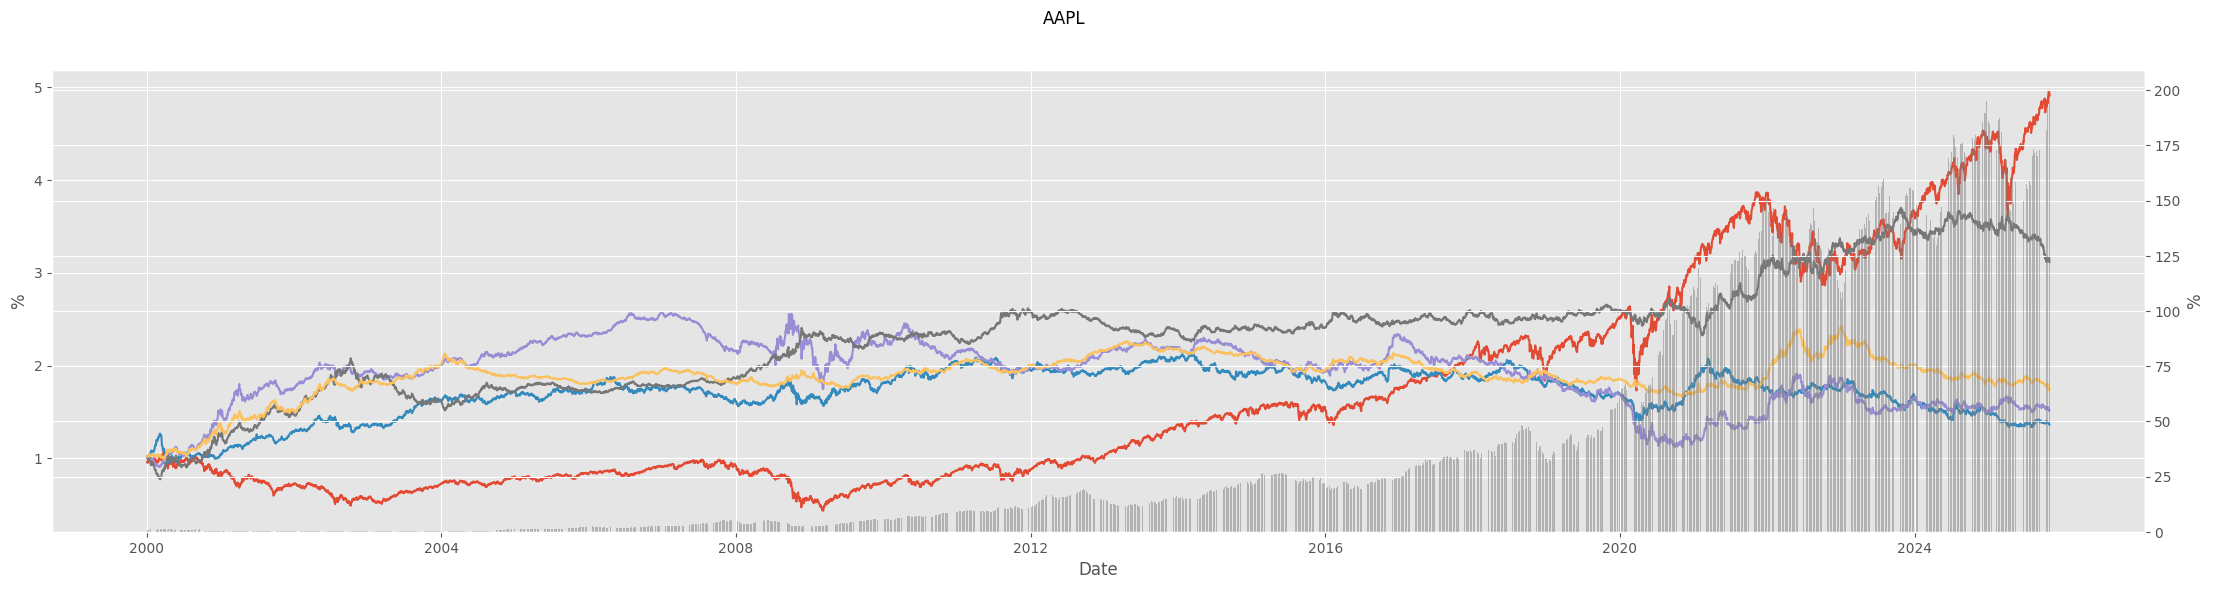

In [37]:
import matplotlib.pyplot as plt
from pandas import DataFrame

plt.style.use("ggplot")

data_percentage: DataFrame = (1 + data / 100) # converts ie. 1.00 = 1% -> 0.01 = 1%
data_percentage_cumprod: DataFrame = data_percentage.cumprod()

figure, axes = plt.subplots(1, 1)
figure.set_figwidth(27)
figure.set_figheight(6)
figure.suptitle(ticker)

axes.plot(data_percentage_cumprod["Mkt-RF"])
axes.plot(data_percentage_cumprod["SMB"])
axes.plot(data_percentage_cumprod["HML"])
axes.plot(data_percentage_cumprod["RMW"])
axes.plot(data_percentage_cumprod["CMA"])
axes.set_ylabel("%")
axes.set_xlabel("Date")
axes_ext: ax.Axes = axes.twinx()

axes_ext.bar(data_percentage_cumprod.index, data_percentage_cumprod["Excess Returns"], color = "grey", alpha = 0.5)
axes_ext.set_ylabel("%")
axes_ext.set_xlabel("Date")

# Multi-linear algorithm definition

In [38]:
import numpy as np

class Metrics():
  @classmethod
  def mean_squared(cls, error: np.ndarray) -> float:
    m: int = error.shape[0]
    return ((error.T @ error) * (1 / m)).item()

  @classmethod
  def root_mean_squared(cls, error: np.ndarray) -> float:
    return np.sqrt(cls.mean_squared(error))

  @classmethod
  def r_squared(cls, error: np.ndarray, variance: np.ndarray) -> float:
    return (1 - ((error.T @ error) / (variance.T @ variance))).item()

In [39]:
import numpy as np

class Multi_Linear_Regression:
  C: np.ndarray 
  M: np.ndarray

  def train(self, x_train: np.ndarray, y_train: np.ndarray, lr: float = 1e-5, epoch: int = 1000) -> None:
    m, n = x_train.shape[0], x_train.shape[1]

    self.M: np.ndarray = np.ones((n, 1), dtype = float)
    self.C: np.ndarray = np.ones((1, 1), dtype = float)
    for _ in range(epoch): 
      y_hat: np.ndarray = (x_train @ self.M) + self.C
      error: np.ndarray = y_hat - y_train

      M_der: np.ndarray = (x_train.T @ error) * (2 / m)
      C_der: np.ndarray = (np.ones(m) @ error) * (2 / m)

      self.C: np.ndarray = self.C - (lr * C_der)
      self.M: np.ndarray = self.M - (lr * M_der)
  
  def predict(self, x_test: np.ndarray) -> np.ndarray | float:
    results: np.ndarray = (x_test @ self.M) + self.C

    if len(results) == 1: return results.item()
    return results


# Pre-training test

In [40]:
from pandas import DataFrame

x: DataFrame = data[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
y: DataFrame = data[["Excess Returns"]]

In [41]:
x.head()

,Mkt-RF,SMB,HML,RMW,CMA
2000-01-04,-4.06,0.34,2.07,0.53,1.36
2000-01-05,-0.09,0.36,-0.05,0.45,1.15
2000-01-06,-0.74,-0.04,1.24,0.64,1.21
2000-01-07,3.21,-0.89,-1.57,-0.83,-1.00
2000-01-10,1.75,0.43,-1.35,-2.20,-0.24


In [42]:
y.head()

,Excess Returns
2000-01-04,-8.450996
2000-01-05,1.443318
2000-01-06,-8.673827
2000-01-07,4.716893
2000-01-10,-1.778824


In [43]:
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# testing the correlation of the data to the market to determine if there even is a correlation to begin with
split: TimeSeriesSplit = TimeSeriesSplit(n_splits = 5)
mean_squared_errors: list = []
root_mean_squared_errors: list = []
r1_scores: list = []

for fold, (train_index, test_index) in enumerate(split.split(x)):
  x_train: np.ndarray = x.iloc[train_index].values
  x_test: np.ndarray = x.iloc[test_index].values
  y_train: np.ndarray = y.iloc[train_index].values
  y_test: np.ndarray = y.iloc[test_index].values

  model: Multi_Linear_Regression = Multi_Linear_Regression()
  model.train(x_train, y_train, lr = 2e-2,epoch = 10000)  

  y_predict: np.ndarray | float = model.predict(x_test)

  mean: np.ndarray = np.mean(y_test, dtype = np.ndarray)
  variance: np.ndarray = y_test - mean
  error: np.ndarray = y_predict - y_test
  
  mean_squared_errors.append(mean_squared_error := Metrics.mean_squared(error))
  root_mean_squared_errors.append(root_mean_squared_error := Metrics.mean_squared(error))
  r1_scores.append(r1_score := Metrics.r_squared(error, variance))

  print(f"Fold: {fold:02}, Mean squared error: {mean_squared_error:2.5f} | Root mean squared error: {root_mean_squared_error:2.5f} | R1 score: {r1_score:2.5f} \n")

print(f"Averages, Mean squared error: {np.mean(mean_squared_errors):2.5f} | Root mean squared error: {np.mean(root_mean_squared_errors):2.5f} | R1 score: {np.mean(r1_scores):2.5f}")

Fold: 00, Mean squared error: 4.76532 | Root mean squared error: 4.76532 | R1 score: 0.23618 

Fold: 01, Mean squared error: 2.58869 | Root mean squared error: 2.58869 | R1 score: 0.49527 

Fold: 02, Mean squared error: 1.87734 | Root mean squared error: 1.87734 | R1 score: 0.23732 

Fold: 03, Mean squared error: 1.71477 | Root mean squared error: 1.71477 | R1 score: 0.57141 

Fold: 04, Mean squared error: 1.72438 | Root mean squared error: 1.72438 | R1 score: 0.45937 

Averages, Mean squared error: 2.53410 | Root mean squared error: 2.53410 | R1 score: 0.39991


# Training the model and testing

In [60]:
from pandas import DataFrame

training_date: str = "2023-01-01"

data_window: DataFrame = data[data.index >= training_date]
x: DataFrame = data_window[["Mkt-RF", "SMB", "HML", "RMW", "CMA"]]
y: DataFrame = data_window[["Excess Returns"]]

<Axes: title={'center': 'Fama-French Cumulative'}, xlabel='Date', ylabel='%'>

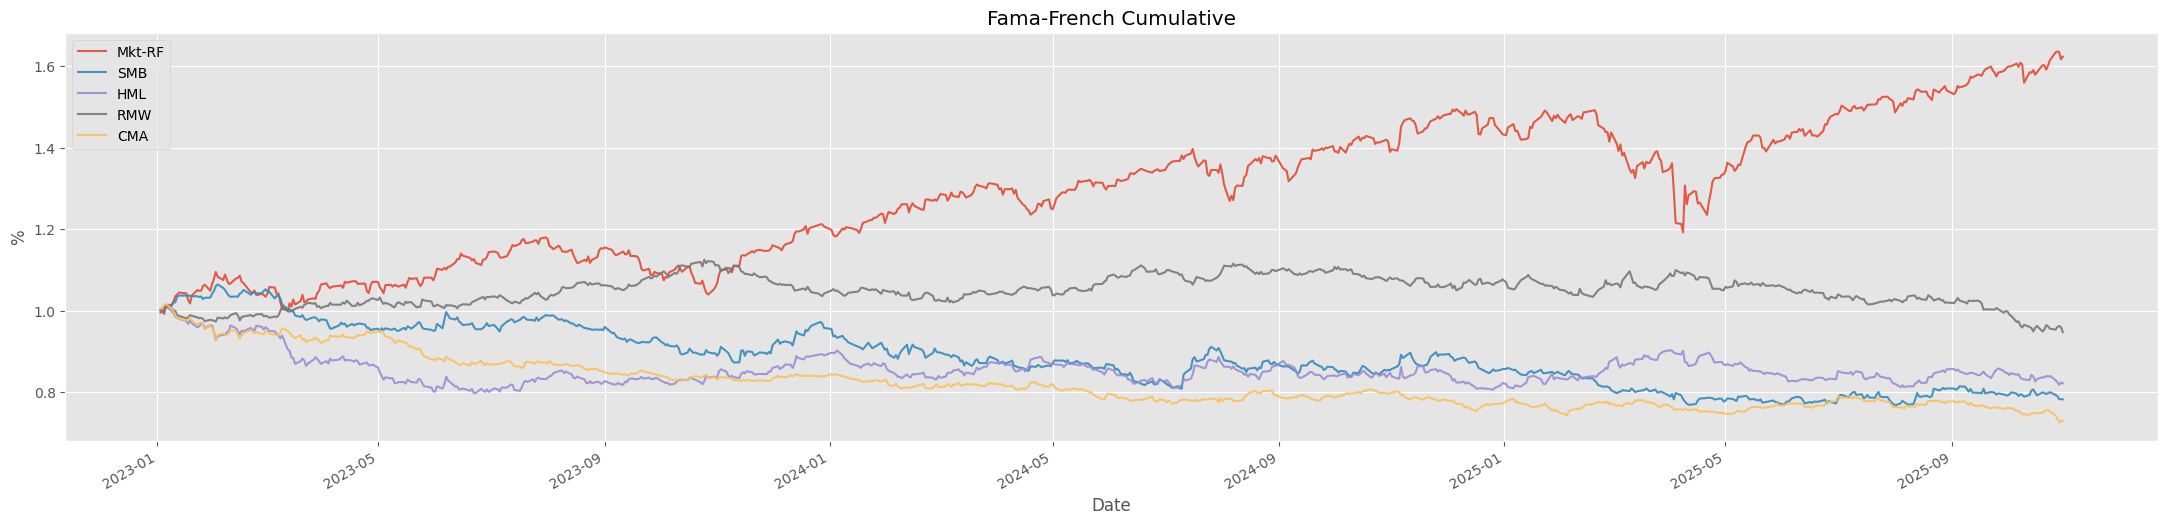

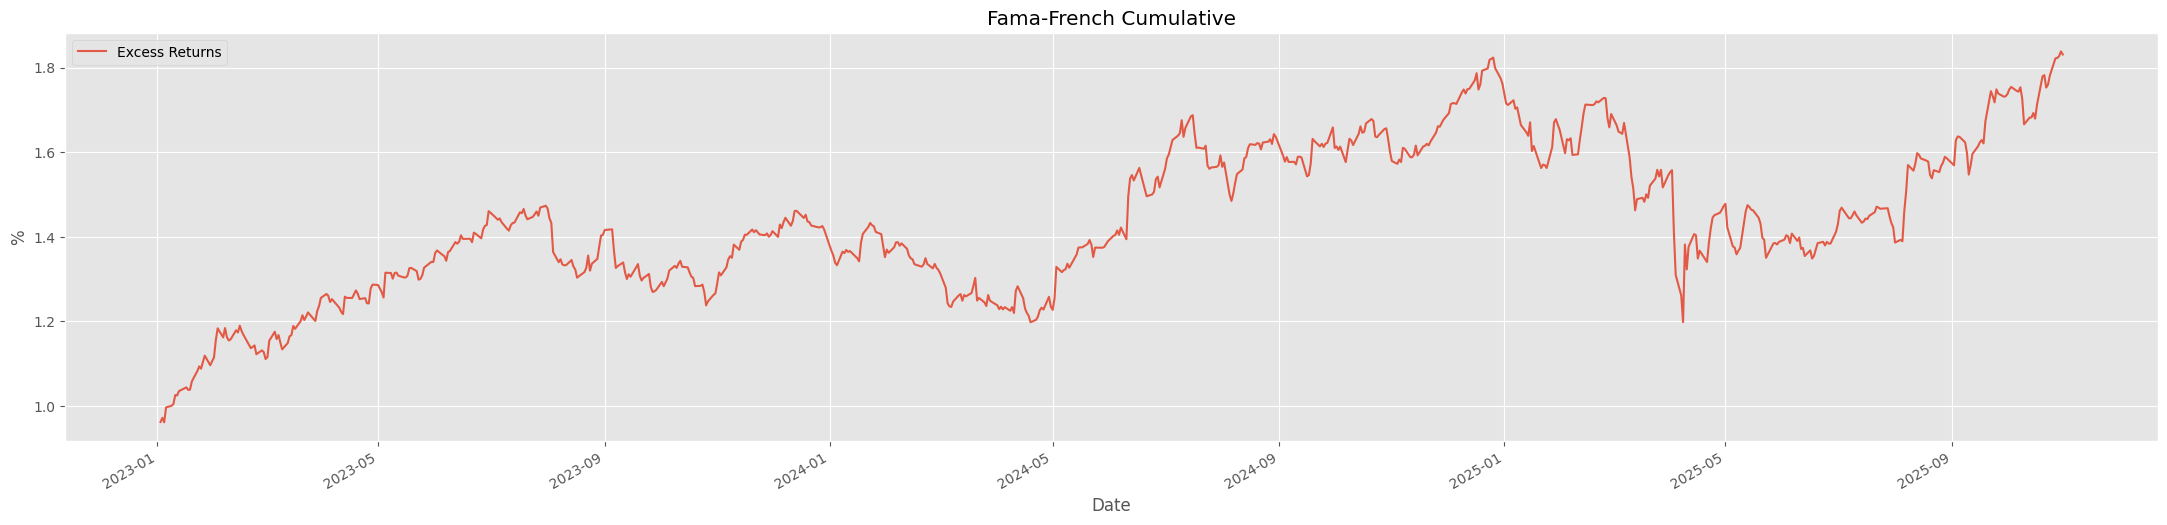

In [61]:
import matplotlib.pyplot as plt
from pandas import DataFrame

plt.style.use("ggplot")

x_percentage: DataFrame = (1 + x / 100) # converts ie. 1.00 = 1% -> 0.01 = 1%
x_percentage_cumprod: DataFrame = x_percentage.cumprod()
x_percentage_cumprod.plot(grid = True, figsize = (27, 6), alpha = 0.9, title = "Fama-French Cumulative", xlabel = "Date", ylabel = "%")

y_percentage: DataFrame = (1 + y / 100) # converts ie. 1.00 = 1% -> 0.01 = 1%
y_percentage_cumprod: DataFrame = y_percentage.cumprod()
y_percentage_cumprod.plot(grid = True, figsize = (27, 6), alpha = 0.9, title = "Fama-French Cumulative", xlabel = "Date", ylabel = "%")

In [126]:
mlr: Multi_Linear_Regression = Multi_Linear_Regression()
window: int = 675

predictions: list = []
dates: list = []
betas: list = []
alphas: list = []

for i in range(window, len(x)):
  x_window = x.iloc[i - window: i]
  y_window = y.iloc[i - window: i]

  mlr.train(x_window.values, y_window.values, lr = 2e-2, epoch = 10000)

  predictions.append(mlr.predict(x.iloc[[i]].values))
  dates.append(x.index[i])

  betas.append(mlr.M.reshape(1, -1)[0])
  alphas.append(mlr.C)

In [53]:
from pandas import DataFrame

results: DataFrame = DataFrame(data = predictions, index = dates, columns = ['Expected_Return'])
results['Actual_Return'] = y.loc[results.index]
results['Alpha'] = results['Actual_Return'] - results['Expected_Return']

In [48]:
results.head()

,Expected_Return,Actual_Return,Alpha
2025-09-12,-0.306297,1.736299,2.042596
2025-09-15,0.891859,1.103591,0.211732
2025-09-16,-0.234924,0.592589,0.827512
2025-09-17,-0.677689,0.332726,1.010415
2025-09-18,-0.531600,-0.484458,0.047143


In [49]:
results.tail()

,Expected_Return,Actual_Return,Alpha
2025-10-27,1.670104,2.259112,0.589008
2025-10-28,0.837369,0.050683,-0.786686
2025-10-29,0.350334,0.240230,-0.110104
2025-10-30,-1.747762,0.610323,2.358085
2025-10-31,-0.279527,-0.399510,-0.119983


In [54]:
from scipy import stats

t_stats, p_value = stats.ttest_1samp(results['Alpha'], 0)

In [128]:
print(f"T-Stats: {t_stats}")
print(f"P-Value: {p_value}")

T-Stats: 2.2535909851895166
P-Value: 0.030589091700921837


In [127]:
from statsmodels.regression.rolling import RollingOLS
import statsmodels.api as sm
from pandas import DataFrame, Series

rollingOLS: RollingOLS = RollingOLS(y, sm.add_constant(x), window = 675)
rolling_betas: DataFrame | Series = rollingOLS.fit().params

if isinstance(rolling_betas, DataFrame):
  print(f"Difference in betas: {(rolling_betas.iloc[:, 1:][window:].values - betas).mean()}")
  print(f"Differences in alphas: {(rolling_betas.iloc[1:, :1][window:].values - alphas).mean()}")

Difference in betas: -0.0004142123955070659
Differences in alphas: 0.00045008207769401396


# Fetching betas and alpha from training

In [140]:
import json
import numpy as np

model_beta: np.ndarray = betas[-1]
model_alpha: float = alphas[-1].item()

with open("fama_french_parameters.json", "w") as file:
  json.dump({"beta": model_beta.tolist(), "alpha": model_alpha}, file)